In [1]:
import os
import torch
import torchvision
from torchvision import datasets, transforms, models
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from google.colab import files

print("Upload your Accident and No_Accident folders as zip file")

Upload your Accident and No_Accident folders as zip file


In [1]:
from google.colab import files
uploaded = files.upload()

Saving sample.zip to sample.zip


In [7]:
import os

In [10]:
import os
import zipfile

with zipfile.ZipFile("sample.zip", "r") as zip_ref:
    zip_ref.extractall("/content/data")

data_dir = "/content/data"

print(os.listdir(data_dir))
print(os.listdir(data_dir + "/Accident"))
print(os.listdir(data_dir + "/No_Accident"))

['No_Accident', 'Accident']
['picture 1.jpg', 'picture 4.jpg', 'picture 3.jpg', 'picture 2.jpg', 'picture 5.jpg']
['NA Picture 5.jpg', 'NA Picture 4.jpg', 'NA Picture 1.jpg', 'NA Picture 2.jpg', 'NA Picture 3.jpg']


In [13]:
import torch
import torchvision

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

In [14]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(data_dir, transform=transform)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, val_data, test_data = random_split(
    dataset,
    [train_size, val_size, test_size]
)

train_loader = DataLoader(train_data, batch_size=4, shuffle=True)
test_loader = DataLoader(test_data, batch_size=4, shuffle=False)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))

Classes: ['Accident', 'No_Accident']
Total images: 10


In [16]:
from torch import nn, optim
from torchvision import models

In [17]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

losses = []

for epoch in range(2):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    losses.append(total_loss)
    print("Epoch", epoch + 1, "Loss:", total_loss)

Epoch 1 Loss: 1.8114205598831177
Epoch 2 Loss: 2.301606774330139


In [19]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

In [20]:
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.numpy())

report = classification_report(
    y_true,
    y_pred,
    target_names=dataset.classes,
    output_dict=True,
    zero_division=0
)

metrics_df = pd.DataFrame(report).transpose()

metrics_df.to_csv("metrics.csv")

metrics_df

,precision,recall,f1-score,support
Accident,0.0,0.0,0.0,2.0
No_Accident,0.0,0.0,0.0,0.0
accuracy,0.0,0.0,0.0,0.0
macro avg,0.0,0.0,0.0,2.0
weighted avg,0.0,0.0,0.0,2.0


In [22]:
import matplotlib.pyplot as plt

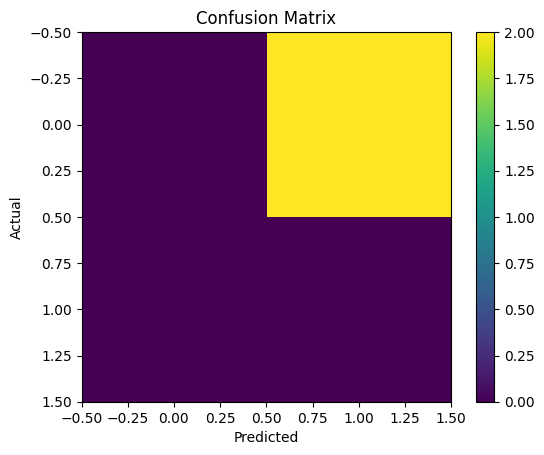

In [23]:
cm = confusion_matrix(y_true, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.savefig("confusion_matrix.png")
plt.show()

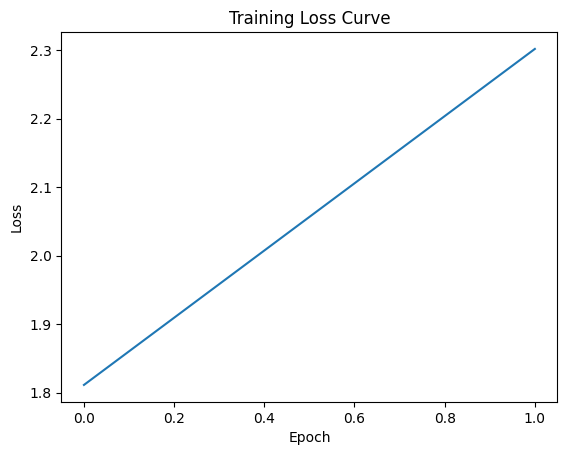

In [24]:
plt.figure()
plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig("loss_curve.png")
plt.show()

In [25]:
from google.colab import files

files.download("metrics.csv")
files.download("confusion_matrix.png")
files.download("loss_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>